# Tensorflow playground with code

Remember when we played witht the tensorflow playground? Well let's do a quick exercise in order to recreate these examples but with code!

## Circle Problem

* 1️⃣ import `make_circles` from sklearn and create an object data containing circle data of 1000 observations, with some noise and a factor of your choice.



In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Generate circular data
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42, factor=0.7)

# Convert to PyTorch tensors
data_tensor = torch.Tensor(X)
target_tensor = torch.Tensor(y)
print(data_tensor)
print(target_tensor)

tensor([[ 0.6457,  0.2206],
        [-0.6354,  0.1524],
        [-0.7306,  0.2094],
        ...,
        [-0.1095, -0.7279],
        [ 0.6609, -0.7932],
        [ 0.2784,  0.9674]])
tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1.,
        1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
        1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
        0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0.,
        1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0.,
        0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
        0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1.,
        1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
        1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.,
        0., 1., 0.

* 2️⃣ Visualize the data

In [84]:
data_tensor.shape

torch.Size([1000, 2])

In [85]:
target_tensor.shape

torch.Size([1000])

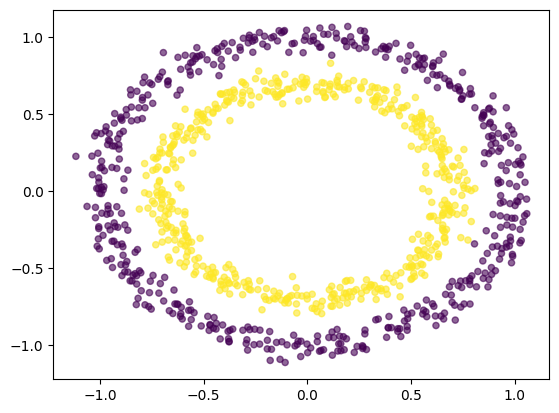

In [86]:
plt.scatter(x=data_tensor[:, 0], y=data_tensor[:, 1], c=target_tensor, cmap="viridis", s=20, alpha=0.6)
plt.show()

* 3️⃣ Split them in train and validation set with sklearn
* 4️⃣ Form two batch datasets, one for training data, one for validation data

In [87]:
# print(X_train.shape)
# print(y_train.shape)
# print(X_val.shape)
# print(y_val.shape)

In [88]:
# for inputs, labels in train_loader:
#     print("Shape de inputs:", inputs.shape)
#     print("Shape de labels:", labels.shape)
#     break  # Juste pour voir le premier batch

In [89]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(data_tensor, target_tensor, test_size=0.3, stratify=y, random_state=42)
# Create DataLoader for batches
train_dataset = data.TensorDataset(X_train, torch.unsqueeze(y_train, 1))
val_dataset = data.TensorDataset(X_val, torch.unsqueeze(y_val, 1))

train_loader = data.DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=200) #augmenter batch_size puisque pas de contrainte de mémoire pour les gradients

* 5️⃣ Create a neural network model in order to make predictions on this dataset, try and make it as simple as possible.

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=4, bias=True)
        self.relu
        self.fc2 = nn.Linear(in_features=4, out_features=1, bias=True)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

simple_model = SimpleNN()
simple_model

SimpleNN(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)

In [91]:
# pip install torchinfo

In [92]:
# Create a dummy input tensor
dummy_tensor = data_tensor[:50] * 1.4 # ou torch.randn(50, 2) 50 lignes avec 2 features

# Get the model output
output = simple_model(dummy_tensor)

# Create and display the computational graph
from torchinfo import summary

summary(simple_model, input_size=(50, 2))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleNN                                 [50, 1]                   --
├─Linear: 1-1                            [50, 4]                   12
├─Linear: 1-2                            [50, 1]                   5
Total params: 17
Trainable params: 17
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [93]:
# summary(simple_model, input_data=dummy_tensor)

In [94]:
from torchviz import make_dot

make_dot(output, params=dict(simple_model.named_parameters())).render("model_architecture", format="png")

'model_architecture.png'

* 6️⃣ Compile the model using Adam and a loss function that suits our problem.

In [95]:
# Binary Cross Entropy Loss
bce = nn.BCELoss()

# optimizer
opt = optim.Adam(simple_model.parameters(), lr=0.001) # Define base learning rate

* 7️⃣ Train the model over 100 epochs

In [96]:
import torch

def train(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    """
    Function to train a PyTorch model with training and validation datasets.
    
    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).
    
    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """
    
    # Dictionary to store training & validation loss and accuracy over epochs
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        # Initialize total loss and correct predictions
        train_loss, correct = 0, 0
        # Training loop
        for inputs, labels in train_loader:
            # Reset gradients before each batch
            optimizer.zero_grad()
            # Forward pass
            outputs = model(inputs)
            # Compute loss
            loss = criterion(outputs, labels)
            # Backpropagation (compute gradients)
            loss.backward()
            # Update model parameters
            optimizer.step()
            # Accumulate batch loss
            train_loss += loss.item()
            # Count correct predictions
            predicted = (outputs >= 0.5).float()
            correct += (predicted == labels).sum().item()
        # Compute average loss and accuracy for training
        train_acc = correct / len(train_loader.dataset)

        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, correct = 0, 0
        # No need to compute gradients during validation
        with torch.no_grad():
            # Forward pass
            for inputs, labels in val_loader:
                outputs = model(inputs)
                # Compute loss
                loss = criterion(outputs, labels)
                # Accumulate validation loss
                val_loss += loss.item()
                # Count correct predictions
                predicted = (outputs >= 0.5).float()
                correct += (predicted == labels).sum().item()
        # Compute average loss and accuracy for validation
        val_acc = correct / len(val_loader.dataset)
        # Store metrics in history dictionary
        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        # Print training progress
        print(f"Epoch {epoch + 1} / {epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    return history  # Return training history

# Train the model
history = train(model=simple_model, train_loader=train_loader, val_loader=val_loader, criterion=bce, optimizer=opt, epochs=100)

Epoch 1 / 100, Train Loss: 9.7453, Val Loss: 1.3831, Train Acc: 0.4429, Val Acc: 0.4800
Epoch 2 / 100, Train Loss: 9.7334, Val Loss: 1.3816, Train Acc: 0.4529, Val Acc: 0.4933
Epoch 3 / 100, Train Loss: 9.7214, Val Loss: 1.3803, Train Acc: 0.4629, Val Acc: 0.5033
Epoch 4 / 100, Train Loss: 9.7085, Val Loss: 1.3789, Train Acc: 0.4657, Val Acc: 0.4967
Epoch 5 / 100, Train Loss: 9.6942, Val Loss: 1.3770, Train Acc: 0.4686, Val Acc: 0.5033
Epoch 6 / 100, Train Loss: 9.6744, Val Loss: 1.3740, Train Acc: 0.4757, Val Acc: 0.5167
Epoch 7 / 100, Train Loss: 9.6488, Val Loss: 1.3703, Train Acc: 0.4886, Val Acc: 0.5233
Epoch 8 / 100, Train Loss: 9.6173, Val Loss: 1.3665, Train Acc: 0.5029, Val Acc: 0.5400
Epoch 9 / 100, Train Loss: 9.5919, Val Loss: 1.3633, Train Acc: 0.5143, Val Acc: 0.5433
Epoch 10 / 100, Train Loss: 9.5735, Val Loss: 1.3607, Train Acc: 0.5086, Val Acc: 0.5433
Epoch 11 / 100, Train Loss: 9.5572, Val Loss: 1.3583, Train Acc: 0.5114, Val Acc: 0.5433
Epoch 12 / 100, Train Loss: 9.

* 8️⃣ Plot the evolution of the train loss and the validation loss and the evolution of the train metric and the validation metric.

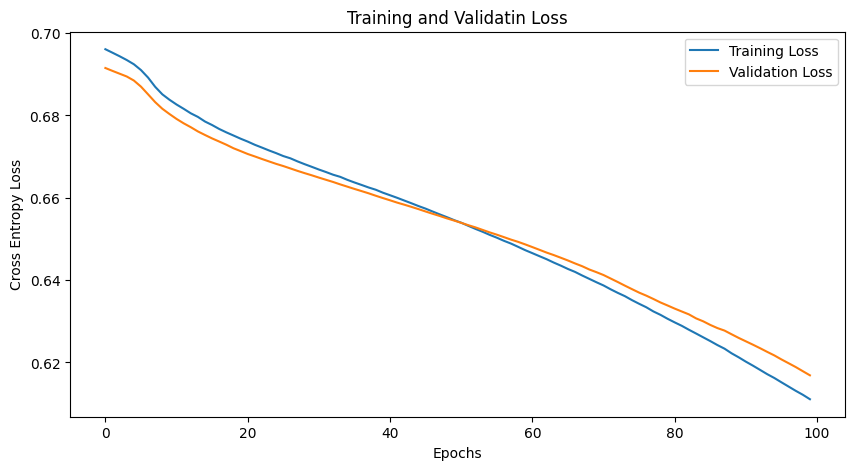

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.title("Training and Validatin Loss")
plt.legend()
plt.show()

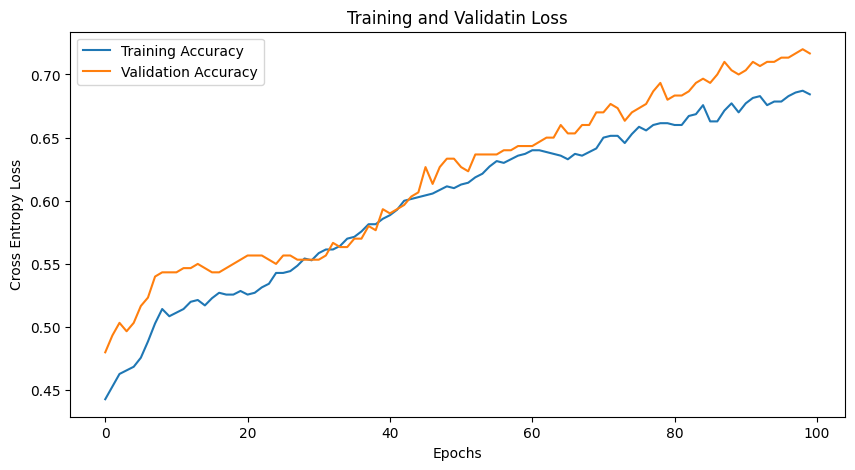

In [98]:
plt.figure(figsize=(10,5))
plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.title("Training and Validatin Loss")
plt.legend()
plt.show()

* 9️⃣ Did the model overfit ?

No it seemed rather that the model underfit! We should increase the learning rate or the number of neurons on our layers.

* 🔟 Can you try and plot the decision function of the model in the data space? Like we saw in the tensorflow playground? You can get inspiration <a href="https://plotly.com/python/knn-classification/"> here </a>

In [99]:
# pip install plotly

In [ ]:
# from plotly import graph_objects as go
# import numpy as np
# color_chart = ["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
# x1_range = np.linspace(-1.5, 1.5, 100)
# x2_range = np.linspace(-1.5, 1.5, 100)
# x1, x2 = np.meshgrid(x1_range, x2_range)
# x_test = np.array([[xx1, xx2] for xx1, xx2 in zip(x1.reshape(-1), x2.reshape(-1))])

# x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
# pred_test = simple_model(x_test_tensor).detach().numpy().reshape(100, 100)

# fig = go.Figure(data=[
#     go.Contour(
#         x=x1_range,
#         y=x2_range,
#         z=pred_test,
#         colorscale=[color_chart[-2], color_chart[-1]]
#     )
# ])
# fig.add_trace(go.Scatter(x=x[:, 0], y=x[:, 1], mode="markers", marker=dict(color=y.numpy(), colorscale=color_chart[0:2])))
# fig.show()


NameError: name 'x' is not defined

## Spiral problem

* 1️⃣ Use the following code to produce some spiral data:

In [ ]:
# import numpy as np
# import torch
# import matplotlib.pyplot as plt

N = 1000
theta = np.sqrt(np.random.rand(N)) * 4 * np.pi

r_a = 2 * theta + np.pi
data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
x_a = data_a + np.random.randn(N, 2)
x_a = x_a / np.abs(x_a).max()

r_b = -2 * theta - np.pi
data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
x_b = data_b + np.random.randn(N, 2)
x_b = x_b / np.abs(x_b).max()

res_a = np.append(x_a, np.zeros((N, 1)), axis=1)
res_b = np.append(x_b, np.ones((N, 1)), axis=1)

res = np.append(res_a, res_b, axis=0)
np.random.shuffle(res)

np.savetxt("result.csv", res, delimiter=",", header="x,y,label", comments="", fmt='%.5f')

data_ten = torch.tensor(res[:, 0:2], dtype=torch.float32)
target = torch.tensor(res[:, -1], dtype=torch.float32)

* 2️⃣ Split into train and validation set

In [ ]:
print(data.shape)
print(target.shape)

torch.Size([2000, 2])
torch.Size([2000])


In [ ]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(data_ten, target, test_size=0.3, stratify=target, random_state=42)
# Create DataLoader for batches
train_dataset = data.TensorDataset(X_train, torch.unsqueeze(y_train, 1))
val_dataset = data.TensorDataset(X_val, torch.unsqueeze(y_val, 1))

train_loader = data.DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=200) #augmenter batch_size puisque pas de contrainte de mémoire pour les gradients

* 3️⃣ Form a train and validation batch dataset

In [ ]:
train_loader

In [ ]:
first_batch = next(iter(train_loader))
print(first_batch)

[tensor([[ 0.7080,  0.4345],
        [ 0.9634, -0.1404],
        [ 0.8510, -0.2977],
        [-0.4693,  0.6896],
        [-0.2562, -0.0164],
        [ 0.3592,  0.7370],
        [-0.3510,  0.8077],
        [ 0.4480,  0.1741],
        [ 0.0216,  0.6486],
        [-0.0848, -0.8298],
        [-0.1002, -0.5949],
        [ 0.8774, -0.2687],
        [-0.3658,  0.6187],
        [ 0.0250, -0.8608],
        [ 0.2827, -0.7867],
        [-0.9338,  0.1962],
        [ 0.4222, -0.4681],
        [ 0.5092,  0.0321],
        [ 0.1440, -0.6457],
        [ 0.2847,  0.1448],
        [-0.1754,  0.8049],
        [ 0.0978,  0.8338],
        [ 0.0011, -0.2088],
        [-0.0581,  0.4471],
        [ 0.1932, -0.1431],
        [-0.4510, -0.4497],
        [-0.3913,  0.8176],
        [ 0.1774,  0.8004],
        [-0.9531, -0.0219],
        [-0.1573,  0.2416],
        [-0.5841, -0.0167],
        [ 0.5903, -0.2809],
        [ 0.5232,  0.0513],
        [ 0.5275,  0.2558],
        [ 0.1591, -0.2418],
        [ 0.3232, -

* 4️⃣ Create a neural network model that can acheive good predictions on the train set (for now we do not care about overfitting)

In [ ]:
print(target[:10])  # Regarde les premières valeurs
print(target.unique())  # Quelles valeurs uniques ?

tensor([0, 1, 1, 1, 1, 1, 1, 0, 1, 1])
tensor([0, 1])


In [ ]:
class modelNN(nn.Module):
    def __init__(self):
        super(modelNN, self).__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=8, bias=True)
        self.fc2 = nn.Linear(in_features=8, out_features=8, bias=True)
        self.fc3 = nn.Linear(in_features=8, out_features=1, bias=True)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

nn_model = modelNN()
nn_model

modelNN(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
)

* 5️⃣ Compile the model with the right loss and metric and Adam optimizer

In [ ]:
# Binary Cross Entropy Loss
bce = nn.BCELoss()

# optimizer
opt = optim.Adam(simple_model.parameters(), lr=0.001) # Define base learning rate

* 6️⃣ Train the model over 100 epochs

In [ ]:
# import torch

def train(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    """
    Function to train a PyTorch model with training and validation datasets.
    
    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).
    
    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """
    
    # Dictionary to store training & validation loss and accuracy over epochs
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        # Initialize total loss and correct predictions
        train_loss, correct = 0, 0
        # Training loop
        for inputs, labels in train_loader:
            # Reset gradients before each batch
            optimizer.zero_grad()
            # Forward pass
            outputs = model(inputs)
            # Compute loss
            loss = criterion(outputs, labels)
            # Backpropagation (compute gradients)
            loss.backward()
            # Update model parameters
            optimizer.step()
            # Accumulate batch loss
            train_loss += loss.item()
            # Count correct predictions
            predicted = (outputs >= 0.5).float()
            correct += (predicted == labels).sum().item()
        # Compute average loss and accuracy for training
        train_acc = correct / len(train_loader.dataset)

        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, correct = 0, 0
        # No need to compute gradients during validation
        with torch.no_grad():
            # Forward pass
            for inputs, labels in val_loader:
                outputs = model(inputs)
                # Compute loss
                loss = criterion(outputs, labels)
                # Accumulate validation loss
                val_loss += loss.item()
                # Count correct predictions
                predicted = (outputs >= 0.5).float()
                correct += (predicted == labels).sum().item()
        # Compute average loss and accuracy for validation
        val_acc = correct / len(val_loader.dataset)
        # Store metrics in history dictionary
        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        # Print training progress
        print(f"Epoch {epoch + 1} / {epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    return history  # Return training history

# Train the model
history = train(model=simple_model, train_loader=train_loader, val_loader=val_loader, criterion=bce, optimizer=opt, epochs=100)

Epoch 1 / 100, Train Loss: 19.8661, Val Loss: 2.0974, Train Acc: 0.4779, Val Acc: 0.4900
Epoch 2 / 100, Train Loss: 19.6990, Val Loss: 2.0809, Train Acc: 0.4671, Val Acc: 0.4917
Epoch 3 / 100, Train Loss: 19.5512, Val Loss: 2.0660, Train Acc: 0.4643, Val Acc: 0.4850
Epoch 4 / 100, Train Loss: 19.4226, Val Loss: 2.0540, Train Acc: 0.4629, Val Acc: 0.4833
Epoch 5 / 100, Train Loss: 19.3147, Val Loss: 2.0439, Train Acc: 0.4693, Val Acc: 0.4967
Epoch 6 / 100, Train Loss: 19.2285, Val Loss: 2.0351, Train Acc: 0.4829, Val Acc: 0.5000
Epoch 7 / 100, Train Loss: 19.1422, Val Loss: 2.0286, Train Acc: 0.4893, Val Acc: 0.5100
Epoch 8 / 100, Train Loss: 19.0733, Val Loss: 2.0222, Train Acc: 0.4936, Val Acc: 0.5217
Epoch 9 / 100, Train Loss: 19.0130, Val Loss: 2.0155, Train Acc: 0.5043, Val Acc: 0.5300
Epoch 10 / 100, Train Loss: 18.9540, Val Loss: 2.0102, Train Acc: 0.5171, Val Acc: 0.5383
Epoch 11 / 100, Train Loss: 18.8946, Val Loss: 2.0055, Train Acc: 0.5236, Val Acc: 0.5467
Epoch 12 / 100, Tra

* 7️⃣ Is the model overfitting? Use visualization

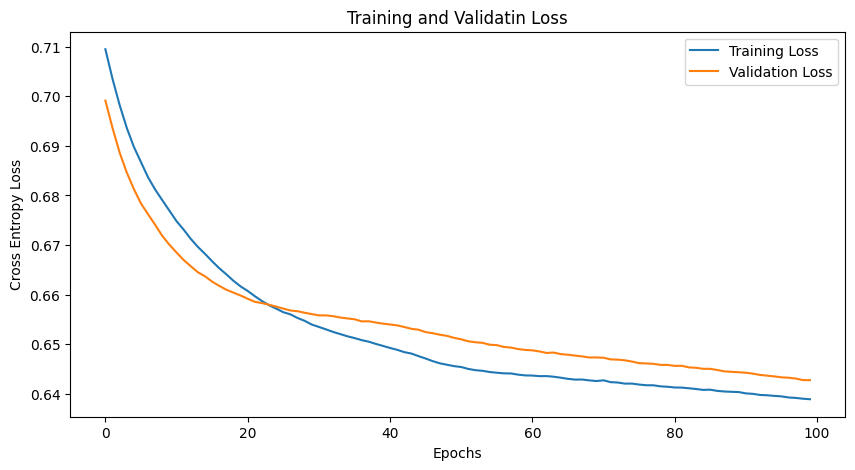

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.title("Training and Validatin Loss")
plt.legend()
plt.show()

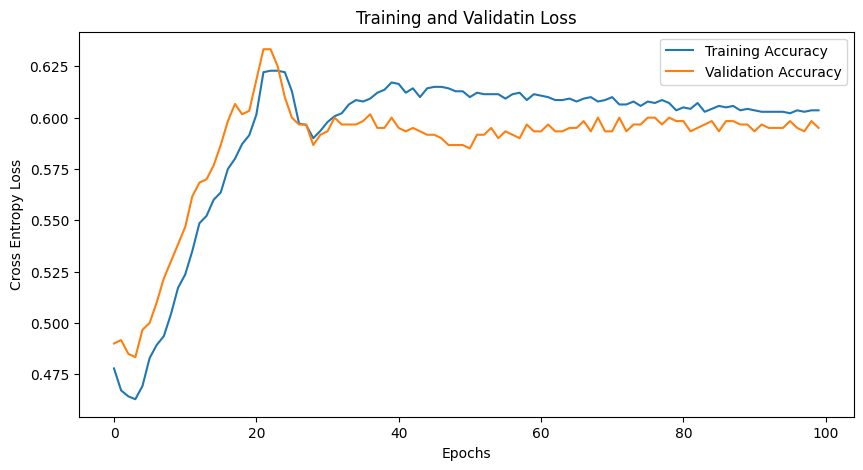

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.title("Training and Validatin Loss")
plt.legend()
plt.show()

* 8️⃣ Visualize the decision boundary, would you say the model could benefit from some regularization?

* 9️⃣ Create a new model and add regularization to each layer, train it and visualize the decision boundary

In [ ]:
class modelNN(nn.Module):
    def __init__(self):
        super(modelNN, self).__init__()
        self.fc1 = nn.Linear(in_features=2, out_features=8, bias=True)
        self.bn1 = nn.BatchNorm1d(8)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(in_features=8, out_features=8, bias=True)
        self.fc3 = nn.Linear(in_features=8, out_features=1, bias=True)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

nn_model = modelNN()
nn_model

modelNN(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
# import torch

def train(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    """
    Function to train a PyTorch model with training and validation datasets.
    
    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).
    
    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """
    
    # Dictionary to store training & validation loss and accuracy over epochs
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        # Initialize total loss and correct predictions
        train_loss, correct = 0, 0
        # Training loop
        for inputs, labels in train_loader:
            # Reset gradients before each batch
            optimizer.zero_grad()
            # Forward pass
            outputs = model(inputs)
            # Compute loss
            loss = criterion(outputs, labels)
            # Backpropagation (compute gradients)
            loss.backward()
            # Update model parameters
            optimizer.step()
            # Accumulate batch loss
            train_loss += loss.item()
            # Count correct predictions
            predicted = (outputs >= 0.5).float()
            correct += (predicted == labels).sum().item()
        # Compute average loss and accuracy for training
        train_acc = correct / len(train_loader.dataset)

        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, correct = 0, 0
        # No need to compute gradients during validation
        with torch.no_grad():
            # Forward pass
            for inputs, labels in val_loader:
                outputs = model(inputs)
                # Compute loss
                loss = criterion(outputs, labels)
                # Accumulate validation loss
                val_loss += loss.item()
                # Count correct predictions
                predicted = (outputs >= 0.5).float()
                correct += (predicted == labels).sum().item()
        # Compute average loss and accuracy for validation
        val_acc = correct / len(val_loader.dataset)
        # Store metrics in history dictionary
        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        # Print training progress
        print(f"Epoch {epoch + 1} / {epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    
    return history  # Return training history

# Train the model
history = train(model=simple_model, train_loader=train_loader, val_loader=val_loader, criterion=bce, optimizer=opt, epochs=100)

Epoch 1 / 100, Train Loss: 17.8829, Val Loss: 1.9278, Train Acc: 0.6021, Val Acc: 0.5933
Epoch 2 / 100, Train Loss: 17.8828, Val Loss: 1.9274, Train Acc: 0.6029, Val Acc: 0.5950
Epoch 3 / 100, Train Loss: 17.8748, Val Loss: 1.9269, Train Acc: 0.6021, Val Acc: 0.5933
Epoch 4 / 100, Train Loss: 17.8719, Val Loss: 1.9265, Train Acc: 0.6029, Val Acc: 0.5917
Epoch 5 / 100, Train Loss: 17.8681, Val Loss: 1.9257, Train Acc: 0.6014, Val Acc: 0.5900
Epoch 6 / 100, Train Loss: 17.8630, Val Loss: 1.9251, Train Acc: 0.6014, Val Acc: 0.5917
Epoch 7 / 100, Train Loss: 17.8557, Val Loss: 1.9247, Train Acc: 0.6014, Val Acc: 0.5917
Epoch 8 / 100, Train Loss: 17.8532, Val Loss: 1.9240, Train Acc: 0.6007, Val Acc: 0.5883
Epoch 9 / 100, Train Loss: 17.8434, Val Loss: 1.9234, Train Acc: 0.6014, Val Acc: 0.5917
Epoch 10 / 100, Train Loss: 17.8380, Val Loss: 1.9228, Train Acc: 0.6021, Val Acc: 0.5917
Epoch 11 / 100, Train Loss: 17.8326, Val Loss: 1.9218, Train Acc: 0.6036, Val Acc: 0.5917
Epoch 12 / 100, Tra

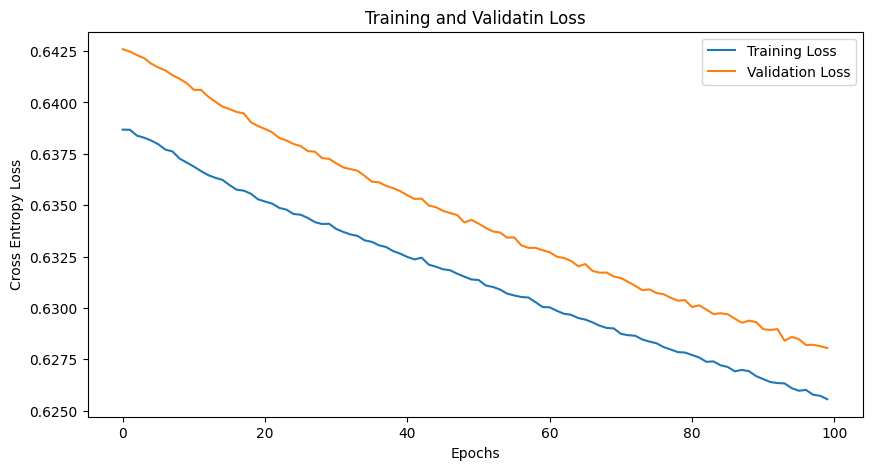

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.title("Training and Validatin Loss")
plt.legend()
plt.show()

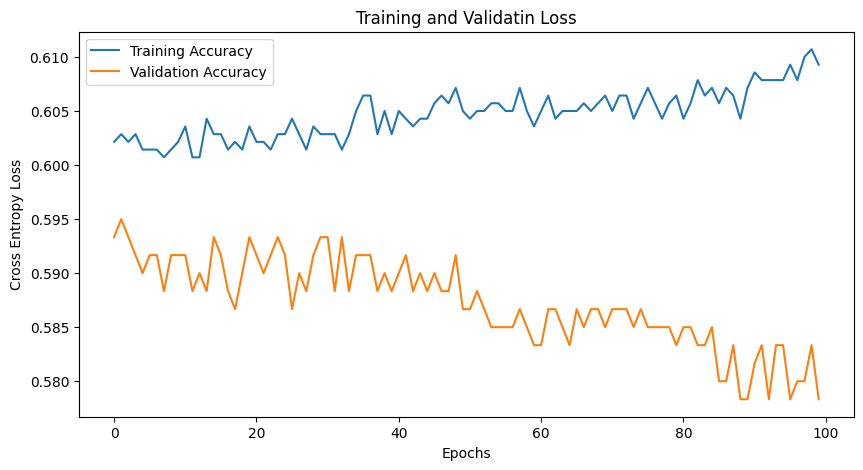

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.title("Training and Validatin Loss")
plt.legend()
plt.show()